# 7.2 MMoE 多目标学习

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

点击与转化既共享信号又不完全相同，怎样让每个任务选择不同的共享专家？

## Setup

本 Notebook 的默认真实数据是 **Census-Income KDD：MMoE/PLE 论文公开多任务实验的完整官方 train/test**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Ma et al., 2018, MMoE](https://dl.acm.org/doi/10.1145/3219819.3220007)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "census-income"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'census-income', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 点击与转化既共享信号又不完全相同，怎样让每个任务选择不同的共享专家？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

MMoE（KDD 2018，Google）针对 Shared-Bottom 对任务相关性敏感的问题：先用合成数据证明相关性越低共享底层越差，再让一组专家被所有任务共享、每个任务配独立 gate。它比 hard sharing 灵活，参数量只多几个轻量 gate；但所有专家仍全量共享，低相关或复杂相关任务下仍可能互相干扰（PLE 论文后来在腾讯系统上测得它对 VCR 的 MTL gain 仅 +0.0001）。

**来源：** [Ma et al., 2018, MMoE](https://dl.acm.org/doi/10.1145/3219819.3220007)

### 原文实验设计与关键结论

原文先用合成数据控制任务相关性：输入 100 维、8 个 16 单元专家、tower 8 单元，每个设置独立重复 200 次——相关性降到 0.5 时 Shared-Bottom 与单门 OMoE 明显退化而 MMoE 几乎不变，且 MMoE 的最终损失方差更小（trainability）。UCI Census-income：299,285 条、40 特征、199,523 训练 + 99,762 测试，两组任务相关性 0.1768/0.2373，每种方法调参后独立训练 400 次；相关性更低的第二组 MMoE 主任务 AUC 最佳 0.8860、均值 0.8826，所有均值优于其他多任务模型。Google 排序：300 亿隐式反馈训练、100 万留出，Table 3 中 AUC@6M 0.6908（Shared-Bottom 0.6900）、R²@6M 0.09362（0.09287）；Table 4 线上 MMoE 相对 Shared-Bottom engagement +0.25%、satisfaction +2.65%。以上是论文系统口径，教程在 Census-income 官方切分与 KuaiRand 上重测的数值不可相减。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Census-Income KDD  
**资源 ID：** `census-income-kdd`  
**切分：** official train/test files  
**指标：** task AUC, task LogLoss  
**与论文比较边界：** compare with MMoE Census-income experiment

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 1 · Shared-bottom, MoE and MMoE](/static/paper-figures/mmoe.webp)

> **论文原图节选** · Figure 1 · Shared-bottom, MoE and MMoE · PDF p.2。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **共享专家网络**：$E$ 个并行前馈子网络各自学习一种可复用表示，所有任务共用。
- **任务专属 Gate**：每个任务独立计算一组 Softmax 权重（对 $E$ 个专家加权），因此点击任务可以偏向专家 1、完播任务偏向专家 3。
- **任务塔**：加权混合后的表示进入每个任务自己的小 MLP 与损失，总损失是多任务加权和。

### 结构：共享专家，任务各自选课

先定记号：输入 $x\in\mathbb R^m$ 是一条样本的 $m$ 维特征；$E$ 个专家网络 $f_1,\dots,f_E$ 结构相同、参数独立，各自输出 $d$ 维向量 $f_e(x)\in\mathbb R^d$；共 $K$ 个任务，任务 $k$ 有自己的门控 $g_k$ 与塔 $t_k$。下标 $e$ 始终表示专家编号，下标 $k$ 始终表示任务编号。

任务 $k$ 的门控是一个线性变换加 softmax：

$$g_k(x)=\mathrm{softmax}(W_{g,k}x),\qquad W_{g,k}\in\mathbb R^{E\times m},$$

即先算 $E$ 个 logit $(W_{g,k}x)_e$，再做 $g_{k,e}(x)=\dfrac{\exp((W_{g,k}x)_e)}{\sum_{e'}\exp((W_{g,k}x)_{e'})}$，得到的 $E$ 个权重和为 1。

手算一组：$E=2$，某条样本的 logits 为 $(2,0)$。$\exp(2)\approx7.389$，$\exp(0)=1$，权重为 $(7.389/8.389,\ 1/8.389)\approx(0.881,0.119)$。若两个专家输出 $f_1(x)=(1,0)$、$f_2(x)=(0,1)$，则任务表示

$$z_k=\sum_{e=1}^{E}g_{k,e}(x)f_e(x)=0.881\times(1,0)+0.119\times(0,1)=(0.881,\ 0.119),$$

近九成取自专家 1；另一条样本若 logits 为 $(0,2)$，配方整个反过来——同一组专家，不同任务、不同样本得到不同混合比例。这正是论文 Figure 6 在真实系统里观察到的门控分布差异。

最终预测再过任务自己的塔：$\hat y_k=\sigma(t_k(z_k))$，$\sigma$ 是 Sigmoid。形状链路：一个 batch 的专家输出堆成 $[B,E,d]$（$B$ 为批大小），task gate 输出 $[B,E]$，逐任务加权求和压成 $[B,d]$，塔输出 $[B,1]$。

总损失是逐任务损失的加权和 $L=\sum_k\lambda_kL_k$；$\lambda_k$ 不只是数学常数，也表达业务权衡（转化样本稀疏时调大 $\lambda_{\text{转化}}$）。注意梯度路径：任务 $k$ 的损失只直接训练自己的 gate 与塔，但所有任务的梯度都会流过共享专家——专家学到的是「按各任务 gate 加权的共同知识」。低相关任务在专家内部打架，正是这一结构的残留风险，也是下一节 PLE 的动机。

### 公式到代码

`run_mmoe` 用相同曝光行产生 click/long-view 两个真实标签；Torch-RecHub MMOE 的专家、gate、任务塔和逐任务 BCE 都能在源码映射中定位。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [多任务标签](/notebooks/3_2_data_ml_basics#observation-label)
- [张量形状与矩阵乘法](/notebooks/3_3_linear_algebra#matmul-embedding)
- [Softmax 与加权和](/notebooks/3_6_information_theory#softmax-temperature)
- [多任务梯度冲突](/notebooks/3_7_optimization#gradient-conflict)

### 本论文新增数学（本节详细推导）

让每个任务用自己的 gate 混合同一组专家，并辨认任务梯度在共享专家中的汇合路径。

任务 $k$ 的表示是专家输出的加权和 $z_k=\sum_e g_{k,e}(x)f_e(x)$，其中 $g_k(x)=\mathrm{softmax}(W_{g,k}x)$：softmax 把任意实数变成和为 1 的权重。手算一组：2 个专家、某条样本的 gate logits 为 $(2,0)$，则 $e^2\approx7.389$、$e^0=1$，权重为 $(7.389/8.389,\ 1/8.389)\approx(0.881,0.119)$，表示近九成来自专家 1；另一条样本 logits 为 $(0,2)$ 时配方整个反过来。专家像擅长不同题型的老师：各任务听同一组老师，但自行决定每位老师占多少。总损失 $L=\sum_k\lambda_kL_k$，$\lambda_k$ 表达业务权衡。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

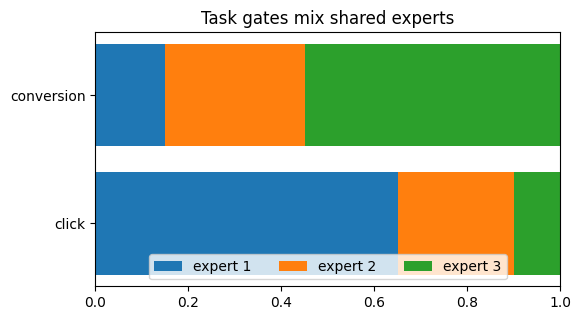

gate sums = [1. 1.]


In [2]:
import numpy as np, matplotlib.pyplot as plt
weights=np.array([[.65,.25,.10],[.15,.30,.55]]); fig,ax=plt.subplots(figsize=(6,3.3)); left=np.zeros(2)
for expert in range(3):
    ax.barh(['click','conversion'],weights[:,expert],left=left,label=f'expert {expert+1}'); left+=weights[:,expert]
ax.set(xlim=(0,1),title='Task gates mix shared experts'); ax.legend(ncol=3,loc='lower center'); plt.show()
print('gate sums =',weights.sum(1))

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** Census-Income KDD  
**资源 ID：** `census-income-kdd`  
**切分：** official train/test files  
**指标：** task AUC, task LogLoss  
**与论文比较边界：** compare with MMoE Census-income experiment

### smoke 教学适配器（默认 runner 实际读取）

KuaiRand-Pure 的真实曝光教学子集，以 `is_click` 和 `long_view` 为两个标签，并共享同一组上下文特征。它只检查多任务梯度与 gate 链路，不冒充 Census-Income 的 income/marital-status 任务。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.multi_task.MMOE；full profile 在 TorchEasyRec 配置专家、任务塔、loss 权重、样本掩码和分布式训练。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.7_2_mmoe.train")
run_mmoe = chapter_train.run_mmoe

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_mmoe))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_mmoe(epochs: int = 28, *, progress: ProgressCallback | None = None) -> dict:
    return _run_multitask("mmoe", epochs, progress=progress)



## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_mmoe(progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载 MMOE 多任务数据


[data_prepare] 1/1 test_rows=1600 train_rows=6400


[train] 0/56 训练 MMOE


[train] 3/56


[train] 6/56


...

[baseline] 1/2


[baseline] 2/2


[evaluate] 0/1 计算多任务 AUC


[evaluate] 1/1 click_auc=0.626282 long_view_auc=0.622082


{'framework': 'torch_rechub.models.multi_task.MMOE', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '<ARTIFACT_ROOT>/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/kuairand-pure/standard_interactions.csv', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 8000, 'train_rows': 6400, 'test_rows': 1600, 'features': 22}, 'device': None, 'validation_mode': None}
inference contract: 共享特征编码一次，任务 gate 混合专家，各塔输出概率；

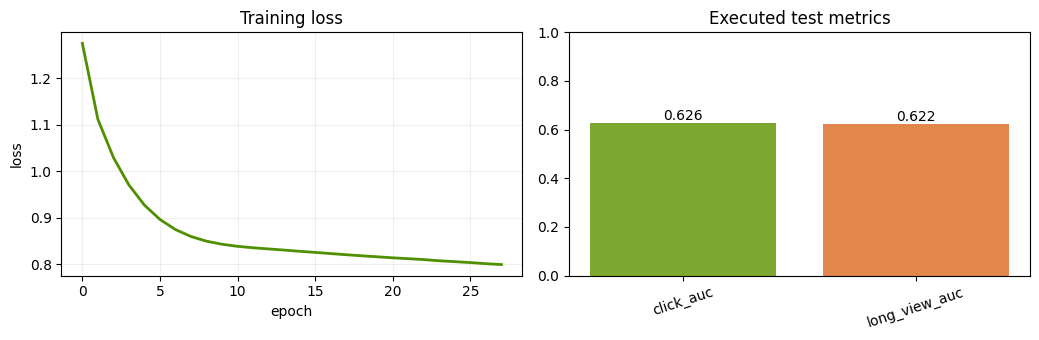

,value
click_auc,0.626282
long_view_auc,0.622082


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'click_auc': result['click_auc'], 'long_view_auc': result['long_view_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Census-Income KDD", "resource": "census-income-kdd", "split": "official train/test files", "metrics": ["task AUC", "task LogLoss"], "paper_comparison": "compare with MMoE Census-income experiment"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 click_auc = **{result['click_auc']:.4f}**。
- 辅助指标 long_view_auc = **{result['long_view_auc']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MMoE 不保证胜过独立模型；任务相关性、标签噪声、loss 尺度和采样空间决定是否正迁移。

### 工业边界

共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 click_auc = **0.6263**。
- 辅助指标 long_view_auc = **0.6221**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **1.2755** 降到 **0.7990**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MMoE 不保证胜过独立模型；任务相关性、标签噪声、loss 尺度和采样空间决定是否正迁移。

### 工业边界

共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'MMoE 多目标学习',
    'primary_metric': 'click_auc', 'primary_value': float(result['click_auc']),
    'secondary_metric': 'long_view_auc', 'secondary_value': float(result['long_view_auc']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '7_2_mmoe',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_7','7_2_mmoe',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_7/7_2_mmoe.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['click_auc']) <= 1
assert np.isfinite(float(result['long_view_auc']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。